# <span style="color:#0f766e; font-weight:700;">Analiza Danych (Python) - Lekcja 6</span>

1. [Czym jest prawdopodobieństwo?](#1.-Czym-jest-prawdopodobieństwo?)
2. [Zdarzenia i działania na zdarzeniach](#2.-Zdarzenia-i-działania-na-zdarzeniach)
3. [Zmienne losowe dyskretne i ciągłe](#3.-Zmienne-losowe-dyskretne-i-ciągłe)
4. [Funkcje pmf, pdf, cdf, ppf](#4.-Funkcje-pmf,-pdf,-cdf,-ppf)
5. [Rozkłady dyskretne w scipy.stats](#5.-Rozkłady-dyskretne-w-scipy.stats)
6. [Rozkłady ciągłe w scipy.stats](#6.-Rozkłady-ciągłe-w-scipy.stats)
7. [Symulacje i prawo wielkich liczb](#7.-Symulacje-i-prawo-wielkich-liczb)
8. [Importy i środowisko](#8.-Importy-i-środowisko)
9. [Przykłady](#9.-Przykłady)
10. [Zadania obowiązkowe](#10.-Zadania-obowiązkowe)
11. [Zadania dodatkowe](#11.-Zadania-dodatkowe)
12. [Najczęstsze błędy](#12.-Najczęstsze-błędy)

# <span style="color:#0f766e; font-weight:700;">1. Czym jest prawdopodobieństwo?</span>

## <span style="color:#0f766e; font-weight:700;">Intuicja częstotliwościowa</span>

Prawdopodobieństwo zdarzenia A to granica, do której zbiega się względna częstość jego wystąpień przy coraz większej liczbie niezależnych powtórzeń eksperymentu:

$$P(A) = \lim_{n \to \infty} \frac{\text{liczba wystąpień A}}{n}$$

W praktyce:
- P(A) ∈ [0, 1]
- P(zdarzenie pewne) = 1
- P(zdarzenie niemożliwe) = 0

## <span style="color:#0f766e; font-weight:700;">Interpretacja</span>

- P(A) = 0.5 oznacza, że w długiej serii doświadczeń zdarzenie A wystąpi mniej więcej w połowie przypadków.
- Im więcej powtórzeń, tym stabilniejsza jest względna częstość (prawo wielkich liczb).


# <span style="color:#0f766e; font-weight:700;">2. Zdarzenia i działania na zdarzeniach</span>

## <span style="color:#0f766e; font-weight:700;">Podstawowe operacje</span>

| Operacja | Zapis | Znaczenie |
|---|---|---|
| Suma logiczna (alternatywa) | A ∪ B | A lub B (lub oba) |
| Iloczyn (koniunkcja) | A ∩ B | A i B jednocześnie |
| Dopełnienie | Aᶜ | nie A |
| Różnica | A \ B | A ale nie B |

## <span style="color:#0f766e; font-weight:700;">Kluczowe reguły</span>

- P(Aᶜ) = 1 − P(A)
- P(A ∪ B) = P(A) + P(B) − P(A ∩ B)
- Jeśli A i B są **rozłączne** (A ∩ B = ∅): P(A ∪ B) = P(A) + P(B)
- Jeśli A i B są **niezależne**: P(A ∩ B) = P(A) · P(B)

## <span style="color:#0f766e; font-weight:700;">Prawdopodobieństwo warunkowe</span>

P(A|B) = P(A ∩ B) / P(B)

Zdarzenia A i B są niezależne wtedy i tylko wtedy, gdy P(A|B) = P(A).

# <span style="color:#0f766e; font-weight:700;">3. Zmienne losowe dyskretne i ciągłe</span>

## <span style="color:#0f766e; font-weight:700;">Zmienna losowa dyskretna</span>

Przyjmuje skończony lub przeliczalny zbiór wartości (0, 1, 2, …).

Przykłady:
- liczba sukcesów w n próbach (Dwumianowy),
- liczba klientów w ciągu godziny (Poissona),
- wynik rzutu kostką.

## <span style="color:#0f766e; font-weight:700;">Zmienna losowa ciągła</span>

Przyjmuje wartości z przedziału liczb rzeczywistych.

Przykłady:
- czas reakcji (ms),
- wzrost człowieka (cm),
- czas między awariami (dni).

## <span style="color:#0f766e; font-weight:700;">Kluczowa różnica</span>

| Cecha | Dyskretna | Ciągła |
|---|---|---|
| Opis rozkładu | pmf (mass function) | pdf (density function) |
| P(X = k) | > 0 możliwe | = 0 (dla punktu) |
| P(a ≤ X ≤ b) | suma pmf | całka pdf |
| Narzędzie scipy | `stats.binom`, `stats.poisson` | `stats.norm`, `stats.expon` |

# <span style="color:#0f766e; font-weight:700;">4. Funkcje pmf, pdf, cdf, ppf</span>

## <span style="color:#0f766e; font-weight:700;">pmf — Probability Mass Function (dyskretna)</span>

pmf(k) = P(X = k)

Suma wszystkich wartości pmf = 1.

## <span style="color:#0f766e; font-weight:700;">pdf — Probability Density Function (ciągła)</span>

pdf(x) — gęstość prawdopodobieństwa w punkcie x.
P(a ≤ X ≤ b) = ∫ₐᵇ pdf(x) dx

Uwaga: pdf(x) może być > 1; to gęstość, nie prawdopodobieństwo.

## <span style="color:#0f766e; font-weight:700;">cdf — Cumulative Distribution Function</span>

cdf(x) = P(X ≤ x) — dla obu typów.
- cdf jest niemalejąca, od 0 do 1.
- P(a < X ≤ b) = cdf(b) − cdf(a)

## <span style="color:#0f766e; font-weight:700;">ppf — Percent Point Function (odwrotność cdf)</span>

ppf(q) = x takie, że P(X ≤ x) = q

Używane do wyznaczania kwantyli i przedziałów centylowych.

## <span style="color:#0f766e; font-weight:700;">Wartość oczekiwana i wariancja</span>

- E[X] — "typowa" wartość zmiennej losowej (`.mean()`)
- Var[X] — miara rozproszenia (`.var()`); SD = √Var[X] (`.std()`)

# <span style="color:#0f766e; font-weight:700;">5. Rozkłady dyskretne w scipy.stats</span>

## <span style="color:#0f766e; font-weight:700;">Bernoulli(p)</span>

Model: jeden eksperyment binarny (sukces/porażka).
- Parametr: p = P(sukces)
- E[X] = p, Var[X] = p(1−p)
- `stats.bernoulli(p)`

## <span style="color:#0f766e; font-weight:700;">Dwumianowy Binomial(n, p)</span>

Model: liczba sukcesów w n niezależnych próbach Bernoulliego.
- Parametry: n (liczba prób), p (P sukcesu w jednej próbie)
- E[X] = np, Var[X] = np(1−p)
- `stats.binom(n, p)`

## <span style="color:#0f766e; font-weight:700;">Poissona(λ)</span>

Model: liczba rzadkich zdarzeń w stałym przedziale czasu/przestrzeni.
- Parametr: λ (lambda) = średnia liczba zdarzeń
- E[X] = λ, Var[X] = λ
- `stats.poisson(mu=λ)`
- Aproksymuje Binomial(n,p) gdy n duże, p małe i np = λ.

# <span style="color:#0f766e; font-weight:700;">6. Rozkłady ciągłe w scipy.stats</span>

## <span style="color:#0f766e; font-weight:700;">Jednostajny Uniform(a, b)</span>

Model: równa szansa na każdą wartość z przedziału [a, b].
- `stats.uniform(loc=a, scale=b-a)`
- E[X] = (a+b)/2, Var[X] = (b−a)²/12

## <span style="color:#0f766e; font-weight:700;">Normalny Normal(μ, σ)</span>

Model: wyniki wielu niezależnych, addytywnych czynników.
- Parametry: μ (mean), σ (std)
- `stats.norm(loc=μ, scale=σ)`
- Reguła 68–95–99.7: 68% danych w μ±σ, 95% w μ±2σ, 99.7% w μ±3σ.

## <span style="color:#0f766e; font-weight:700;">Wykładniczy Exponential(scale=1/λ)</span>

Model: czas oczekiwania na pierwsze zdarzenie Poissona.
- Parametr: scale = 1/λ (średni czas między zdarzeniami)
- `stats.expon(scale=1/λ)`
- E[X] = 1/λ, Var[X] = 1/λ²
- Własność braku pamięci: P(X > s+t | X > s) = P(X > t)

# <span style="color:#0f766e; font-weight:700;">7. Symulacje i prawo wielkich liczb</span>

## <span style="color:#0f766e; font-weight:700;">Prawo wielkich liczb</span>

Gdy powtarzamy eksperyment coraz więcej razy, średnia z wyników zbiega do wartości oczekiwanej E[X].

W scipy.stats każdy rozkład ma metodę `.rvs(size=n)` — generuje n losowych próbek.

## <span style="color:#0f766e; font-weight:700;">Dlaczego symulacje są użyteczne?</span>

- Weryfikacja intuicji probabilistycznej.
- Przybliżone obliczenia, gdy analityczne są trudne.
- Demonstracja zbieżności (prawo wielkich liczb, CTG).

## <span style="color:#0f766e; font-weight:700;">Powtarzalność: np.random.seed / rng</span>

Ustawiaj ziarno losowości, aby wyniki były powtarzalne:
```python
np.random.seed(42)          # stary API
rng = np.random.default_rng(42)  # nowy API (zalecany)
```

# <span style="color:#0f766e; font-weight:700;">8. Importy i środowisko</span>

Zainstaluj brakujące pakiety:
```bash
pip install scipy numpy pandas matplotlib seaborn
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ustawienia globalne wykresów
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (8, 4)

print("Biblioteki wczytane pomyślnie.")
print(f"scipy wersja: {stats.norm.version if hasattr(stats.norm, 'version') else 'ok'}")

Biblioteki wczytane pomyślnie.
scipy wersja: ok


# <span style="color:#0f766e; font-weight:700;">9. Przykłady</span>

## <span style="color:#0f766e; font-weight:700;">Przykład 1: Intuicja częstotliwościowa — symulacja rzutu monetą</span>

Wraz ze wzrostem liczby rzutów, względna częstość orła zbiega do P(orzeł) = 0.5.

n=   10: P(orzeł) ≈ 0.4000
n=  100: P(orzeł) ≈ 0.5200
n= 1000: P(orzeł) ≈ 0.5090
n= 5000: P(orzeł) ≈ 0.4940


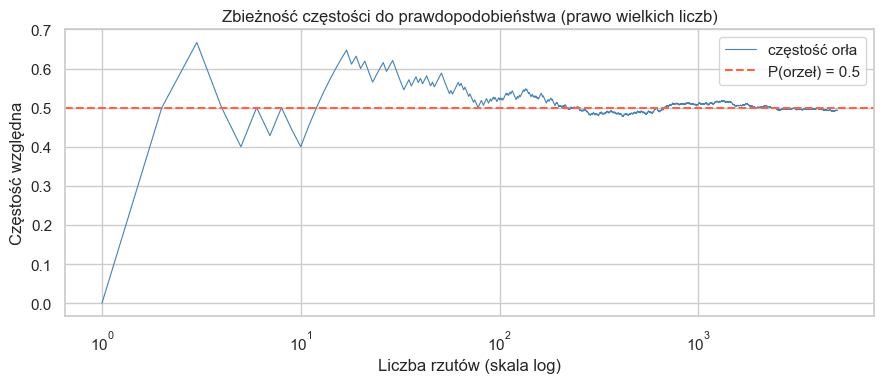

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Ziarno losowości dla powtarzalności
rng = np.random.default_rng(42)

# Symulacja rzutu monetą: 0 = reszka, 1 = orzeł
n_max = 5000
wyniki = rng.integers(0, 2, size=n_max)

# Kumulująca się częstość orła po każdym rzucie
kum_czestosci = np.cumsum(wyniki) / np.arange(1, n_max + 1)

# Wynik dla wybranych n
for n in [10, 100, 1000, 5000]:
    print(f"n={n:5d}: P(orzeł) ≈ {kum_czestosci[n-1]:.4f}")

# Wykres zbieżności
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, n_max + 1), kum_czestosci, color='steelblue', lw=0.8, label='częstość orła')
plt.axhline(0.5, color='tomato', linestyle='--', lw=1.5, label='P(orzeł) = 0.5')
plt.xscale('log')
plt.xlabel('Liczba rzutów (skala log)')
plt.ylabel('Częstość względna')
plt.title('Zbieżność częstości do prawdopodobieństwa (prawo wielkich liczb)')
plt.legend()
plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Przykład 2: Rozkład Bernoulliego — pmf i podstawowe własności</span>

Rozkład Bernoulliego opisuje jeden eksperyment z dwoma wynikami. Używamy go jako cegiełki do budowy rozkładu dwumianowego.

In [3]:
from scipy import stats

# Rozkład Bernoulliego: p = prawdopodobieństwo sukcesu
p = 0.3
dist = stats.bernoulli(p)

# Funkcja masy prawdopodobieństwa (pmf)
print("--- Rozkład Bernoulliego(p=0.3) ---")
print(f"P(X=0) = pmf(0) = {dist.pmf(0):.4f}  (porażka)")
print(f"P(X=1) = pmf(1) = {dist.pmf(1):.4f}  (sukces)")

# Funkcja rozkładu skumulowanego (cdf)
print(f"\nP(X≤0) = cdf(0) = {dist.cdf(0):.4f}")
print(f"P(X≤1) = cdf(1) = {dist.cdf(1):.4f}")

# Własności rozkładu
print(f"\nE[X]   = {dist.mean():.4f}  (= p = {p})")
print(f"Var[X] = {dist.var():.4f}  (= p*(1-p) = {p*(1-p):.4f})")
print(f"SD[X]  = {dist.std():.4f}")

--- Rozkład Bernoulliego(p=0.3) ---
P(X=0) = pmf(0) = 0.7000  (porażka)
P(X=1) = pmf(1) = 0.3000  (sukces)

P(X≤0) = cdf(0) = 0.7000
P(X≤1) = cdf(1) = 1.0000

E[X]   = 0.3000  (= p = 0.3)
Var[X] = 0.2100  (= p*(1-p) = 0.2100)
SD[X]  = 0.4583


## <span style="color:#0f766e; font-weight:700;">Przykład 3: Rozkład Dwumianowy — pmf, cdf i wykres</span>

n=15 pytań testowych, P(dobra odpowiedź) = 0.4. Jaka jest szansa na różne wyniki?

--- Binomial(n=15, p=0.4) ---
P(X=6)      = 0.2066
P(X≤6)      = 0.6098
P(X≥10)     = 0.0338  [= 1 - P(X≤9)]
P(4≤X≤8)    = 0.8145

E[X]  = 6.00  (= n*p = 6.0)
Var[X]= 3.60  (= n*p*(1-p) = 3.60)


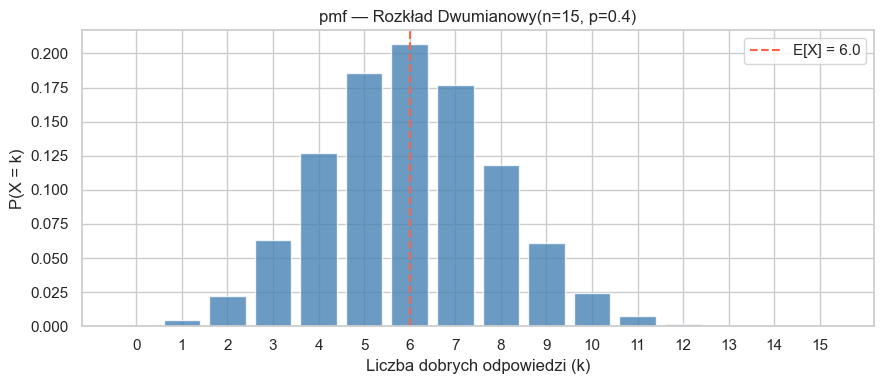

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n, p = 15, 0.4
dist = stats.binom(n, p)

# Obliczenia pmf i cdf
print(f"--- Binomial(n={n}, p={p}) ---")
print(f"P(X=6)      = {dist.pmf(6):.4f}")
print(f"P(X≤6)      = {dist.cdf(6):.4f}")
print(f"P(X≥10)     = {1 - dist.cdf(9):.4f}  [= 1 - P(X≤9)]")
print(f"P(4≤X≤8)    = {dist.cdf(8) - dist.cdf(3):.4f}")
print(f"\nE[X]  = {dist.mean():.2f}  (= n*p = {n*p})")
print(f"Var[X]= {dist.var():.2f}  (= n*p*(1-p) = {n*p*(1-p):.2f})")

# Wykres pmf
k_values = np.arange(0, n + 1)
pmf_values = dist.pmf(k_values)

plt.figure(figsize=(9, 4))
plt.bar(k_values, pmf_values, color='steelblue', alpha=0.8)
plt.axvline(dist.mean(), color='tomato', linestyle='--', lw=1.5, label=f'E[X] = {dist.mean():.1f}')
plt.xlabel('Liczba dobrych odpowiedzi (k)')
plt.ylabel('P(X = k)')
plt.title(f'pmf — Rozkład Dwumianowy(n={n}, p={p})')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Przykład 4: Rozkład Poissona — modelowanie rzadkich zdarzeń</span>

Sklep obsługuje średnio λ=3 klientów na godzinę. Jaka jest szansa, że w danej godzinie przyjdzie dokładnie k klientów?

--- Poisson(λ=3.0) ---
P(X=0)   = 0.0498  (brak klientów)
P(X=3)   = 0.2240  (dokładnie λ klientów)
P(X≤5)   = 0.9161
P(X>5)   = 0.0839  [= 1 - P(X≤5)]

E[X]   = 3.00  (= λ)
Var[X] = 3.00  (= λ)


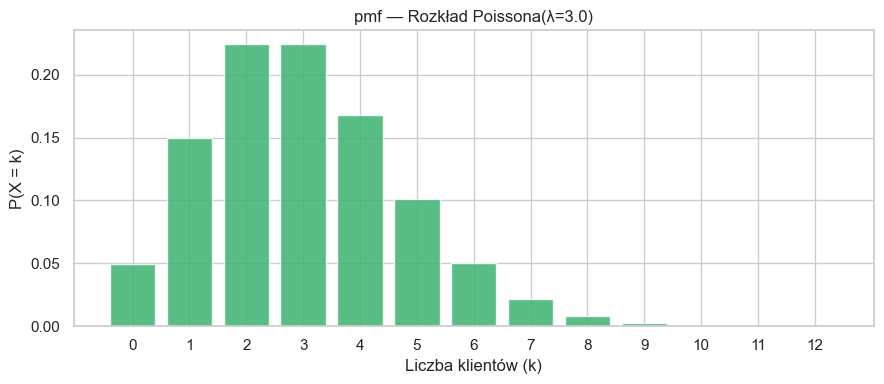

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

lam = 3.0
dist = stats.poisson(mu=lam)

print(f"--- Poisson(λ={lam}) ---")
print(f"P(X=0)   = {dist.pmf(0):.4f}  (brak klientów)")
print(f"P(X=3)   = {dist.pmf(3):.4f}  (dokładnie λ klientów)")
print(f"P(X≤5)   = {dist.cdf(5):.4f}")
print(f"P(X>5)   = {1 - dist.cdf(5):.4f}  [= 1 - P(X≤5)]")
print(f"\nE[X]   = {dist.mean():.2f}  (= λ)")
print(f"Var[X] = {dist.var():.2f}  (= λ)")

# Wykres pmf
k_values = np.arange(0, 13)
pmf_values = dist.pmf(k_values)

plt.figure(figsize=(9, 4))
plt.bar(k_values, pmf_values, color='mediumseagreen', alpha=0.85)
plt.xlabel('Liczba klientów (k)')
plt.ylabel('P(X = k)')
plt.title(f'pmf — Rozkład Poissona(λ={lam})')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Przykład 5: Rozkład Normalny — pdf, cdf, ppf i obszary pod krzywą</span>

Wzrost dorosłych: μ=172 cm, σ=8 cm. Obliczamy prawdopodobieństwa i kwantyle.

--- Normal(μ=172, σ=8) ---
P(X < 160)      = 0.0668
P(160 < X < 185)= 0.8811
P(X > 190)      = 0.0122
P(μ±1σ) = P(164 < X < 180) = 0.6827
P(μ±2σ) = P(156 < X < 188) = 0.9545
P(μ±3σ) = P(148 < X < 196) = 0.9973

Mediana (50.p.)    = 172.0 cm
Q1 (25. percentyl) = 166.6 cm
Q3 (75. percentyl) = 177.4 cm
95. percentyl      = 185.2 cm


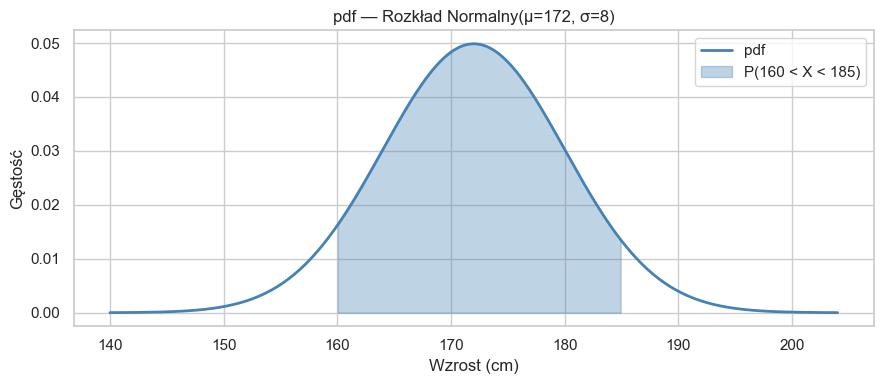

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

mu, sigma = 172, 8
dist = stats.norm(loc=mu, scale=sigma)

# Prawdopodobieństwa z cdf
print(f"--- Normal(μ={mu}, σ={sigma}) ---")
print(f"P(X < 160)      = {dist.cdf(160):.4f}")
print(f"P(160 < X < 185)= {dist.cdf(185) - dist.cdf(160):.4f}")
print(f"P(X > 190)      = {1 - dist.cdf(190):.4f}")

# Reguła 68-95-99.7
for k in [1, 2, 3]:
    p = dist.cdf(mu + k*sigma) - dist.cdf(mu - k*sigma)
    print(f"P(μ±{k}σ) = P({mu-k*sigma:.0f} < X < {mu+k*sigma:.0f}) = {p:.4f}")

# Kwantyle (ppf)
print(f"\nMediana (50.p.)    = {dist.ppf(0.50):.1f} cm")
print(f"Q1 (25. percentyl) = {dist.ppf(0.25):.1f} cm")
print(f"Q3 (75. percentyl) = {dist.ppf(0.75):.1f} cm")
print(f"95. percentyl      = {dist.ppf(0.95):.1f} cm")

# Wykres pdf z zaznaczonym obszarem
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf_values = dist.pdf(x)

plt.figure(figsize=(9, 4))
plt.plot(x, pdf_values, color='steelblue', lw=2, label='pdf')
# Zaznaczenie P(160 < X < 185)
mask = (x >= 160) & (x <= 185)
plt.fill_between(x[mask], pdf_values[mask], alpha=0.35, color='steelblue', label='P(160 < X < 185)')
plt.xlabel('Wzrost (cm)')
plt.ylabel('Gęstość')
plt.title(f'pdf — Rozkład Normalny(μ={mu}, σ={sigma})')
plt.legend()
plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Przykład 6: Rozkład Wykładniczy — czas między zdarzeniami</span>

Czas między kolejnymi awarami maszyny ma rozkład wykładniczy ze średnią 5 dni.

--- Exponential(scale=5.0) ---
P(X ≤ 2)  = 0.3297  (awaria w ciągu 2 dni)
P(X > 7)  = 0.2466  (spokój przez 7+ dni)
Mediana   = 3.47 dni
E[X]      = 5.00 dni


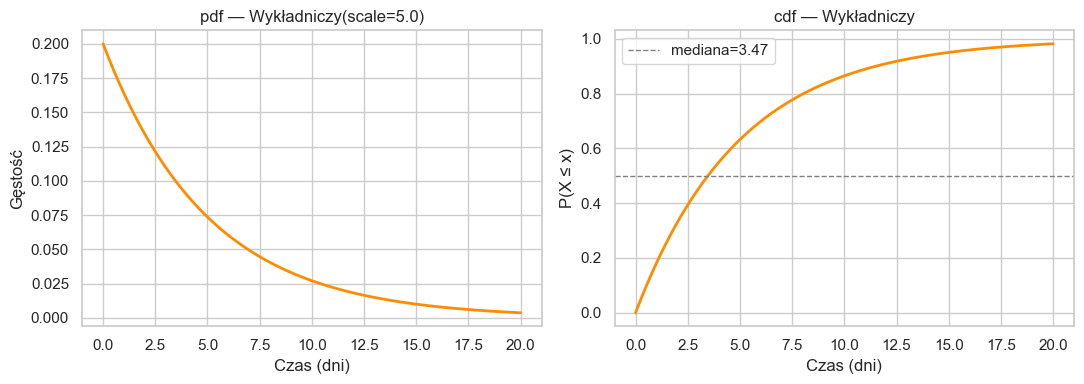

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# scale = 1/lambda = średni czas oczekiwania
scale = 5.0
dist = stats.expon(scale=scale)

print(f"--- Exponential(scale={scale}) ---")
print(f"P(X ≤ 2)  = {dist.cdf(2):.4f}  (awaria w ciągu 2 dni)")
print(f"P(X > 7)  = {1 - dist.cdf(7):.4f}  (spokój przez 7+ dni)")
print(f"Mediana   = {dist.ppf(0.5):.2f} dni")
print(f"E[X]      = {dist.mean():.2f} dni")

# Wykres pdf i cdf obok siebie
x = np.linspace(0, 20, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x, dist.pdf(x), color='darkorange', lw=2)
axes[0].set_xlabel('Czas (dni)')
axes[0].set_ylabel('Gęstość')
axes[0].set_title(f'pdf — Wykładniczy(scale={scale})')

axes[1].plot(x, dist.cdf(x), color='darkorange', lw=2)
axes[1].axhline(0.5, color='gray', linestyle='--', lw=1, label=f'mediana={dist.ppf(0.5):.2f}')
axes[1].set_xlabel('Czas (dni)')
axes[1].set_ylabel('P(X ≤ x)')
axes[1].set_title('cdf — Wykładniczy')
axes[1].legend()

plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Przykład 7: Symulacja vs rozkład teoretyczny</span>

Generujemy próbkę z rozkładu normalnego i porównujemy histogram z teoretycznym pdf.

Parametry rozkładu: μ=50, σ=10
Próbkowe statystyki (n=1000): mean=49.71, std=9.89


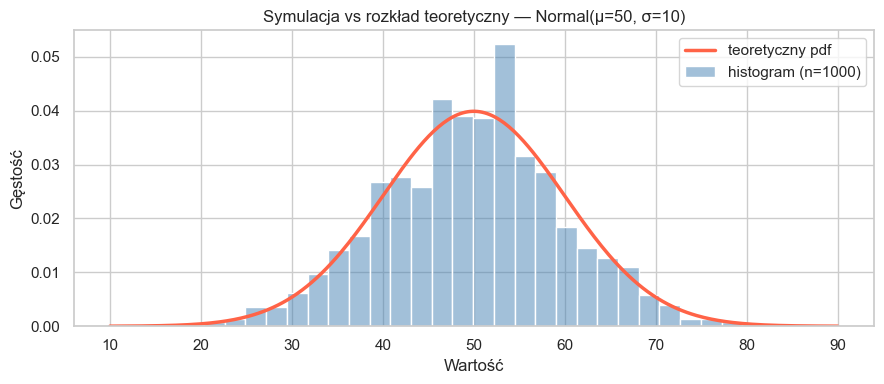

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

mu, sigma = 50, 10
rng = np.random.default_rng(42)

# Losowanie próbki
n = 1000
probka = stats.norm(mu, sigma).rvs(size=n, random_state=rng)

# Statystyki próbkowe vs parametry
print(f"Parametry rozkładu: μ={mu}, σ={sigma}")
print(f"Próbkowe statystyki (n={n}): mean={probka.mean():.2f}, std={probka.std():.2f}")

# Wykres
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
dist = stats.norm(mu, sigma)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(probka, stat='density', bins=30, ax=ax, color='steelblue', alpha=0.5, label='histogram (n=1000)')
ax.plot(x, dist.pdf(x), color='tomato', lw=2.5, label='teoretyczny pdf')
ax.set_xlabel('Wartość')
ax.set_ylabel('Gęstość')
ax.set_title(f'Symulacja vs rozkład teoretyczny — Normal(μ={mu}, σ={sigma})')
ax.legend()
plt.tight_layout()
plt.show()

# <span style="color:#0f766e; font-weight:700;">10. Zadania obowiązkowe</span>

## <span style="color:#0f766e; font-weight:700;">Zadanie 1</span>

Symulacja eksperymentu losowego — rzut sześcienną kostką.

Instrukcja:
1. Zasymuluj 2000 rzutów kostką sześcienną (wyniki: 1–6) korzystając z `np.random.default_rng`.
2. Oblicz względną częstość każdej ściany.
3. Narysuj wykres słupkowy częstości empirycznych. Dorysuj poziomą linię przerywaną na poziomie 1/6 (częstość teoretyczna).
4. Oblicz i wydrukuj odchylenie bezwzględne każdej empirycznej częstości od 1/6.

Wymagane funkcje:
- `rng.integers()` — generuje losowe liczby całkowite
- `np.unique()` z parametrem `return_counts=True` lub `pd.Series.value_counts()`
- `plt.bar()` — wykres słupkowy
- `plt.axhline()` — pozioma linia referencyjna

Kryterium zaliczenia:
- względne częstości obliczone poprawnie (suma = 1.0),
- wykres z linią 1/6,
- odchylenia wydrukowane dla każdej ściany.

Checkpoint:
- pokaż prowadzącemu wykres i wydrukowane odchylenia.

Dokumentacja:
- https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.integers.html
- https://numpy.org/doc/stable/reference/generated/numpy.unique.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 2</span>

Obliczanie prawdopodobieństwa sumy i iloczynu zdarzeń.

Instrukcja:
1. Korzystając z symulacji z Zadania 1 (2000 rzutów kostką), zdefiniuj dwa zdarzenia:
   - A: wynik jest **parzysty** (2, 4, 6),
   - B: wynik jest **większy niż 4** (5, 6).
2. Oblicz empirycznie: P(A), P(B), P(A ∩ B), P(A ∪ B).
3. Sprawdź regułę addytywności: P(A ∪ B) = P(A) + P(B) − P(A ∩ B).
4. Sprawdź, czy A i B są niezależne: porównaj P(A ∩ B) z P(A) · P(B).

Wymagane funkcje:
- operacje na tablicach numpy (maski logiczne: `&`, `|`)
- `np.mean()` — oblicza średnią (czyli empiryczne prawdopodobieństwo dla masek logicznych)

Kryterium zaliczenia:
- poprawne obliczenia P(A), P(B), P(A∩B), P(A∪B),
- sprawdzenie reguły addytywności (różnica ≈ 0),
- wniosek o niezależności/zależności A i B.

Checkpoint:
- pokaż wydrukowane wartości prawdopodobieństw i wynik porównania.

Dokumentacja:
- https://numpy.org/doc/stable/reference/generated/numpy.mean.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 3</span>

Rozkład Bernoulliego — obliczenia i weryfikacja własności.

Instrukcja:
1. Utwórz rozkład Bernoulliego dla p = 0.25.
2. Oblicz pmf(0), pmf(1), cdf(0), cdf(1).
3. Oblicz E[X] i Var[X] korzystając z metod scipy.
4. Zweryfikuj analitycznie: sprawdź, czy E[X] = p i Var[X] = p·(1−p).

Wymagane funkcje:
- `stats.bernoulli(p)` — tworzy obiekt rozkładu Bernoulliego
- `.pmf()`, `.cdf()`, `.mean()`, `.var()` — metody obiektu rozkładu

Kryterium zaliczenia:
- poprawnie obliczone pmf, cdf, E[X], Var[X],
- numeryczna weryfikacja wzorów (różnica < 1e-10).

Checkpoint:
- pokaż wydrukowane wartości i wynik weryfikacji.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bernoulli.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 4</span>

Rozkład Dwumianowy — pmf, cdf i wykres.

Instrukcja:
1. Student rozwiązuje 12-pytaniowy test, P(poprawna odpowiedź) = 0.55.
2. Oblicz:
   - P(X = 7),
   - P(X ≥ 9),
   - P(4 ≤ X ≤ 8).
3. Narysuj wykres pmf dla k = 0, …, 12. Zaznacz słupki, dla których k ≥ 9, innym kolorem.

Wymagane funkcje:
- `stats.binom(n, p)` — tworzy obiekt rozkładu dwumianowego
- `.pmf()`, `.cdf()`, `.mean()`, `.std()` — metody obiektu rozkładu
- `plt.bar()` z parametrem `color` jako lista — różne kolory słupków

Kryterium zaliczenia:
- trzy poprawne wartości prawdopodobieństwa,
- wykres pmf z wyróżnionymi słupkami k ≥ 9.

Checkpoint:
- pokaż prowadzącemu obliczenia i wykres.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 5</span>

Rozkład Dwumianowy — ppf i przedziały centylowe.

Instrukcja:
1. Korzystając z tego samego rozkładu co w Zadaniu 4 (n=12, p=0.55):
2. Wyznacz 10., 25., 50., 75. i 90. percentyl korzystając z `ppf`.
3. Oblicz "typowy" zakres wyników: przedział [Q1, Q3].
4. Wyjaśnij (krótki komentarz w kodzie), dlaczego ppf zwraca liczby całkowite.

Wymagane funkcje:
- `stats.binom.ppf(q)` lub `dist.ppf(q)` — kwantyl rozkładu
- `dist.interval(confidence)` — opcjonalnie

Kryterium zaliczenia:
- poprawne percentyle (5 wartości),
- zakres [Q1, Q3] wydrukowany.

Checkpoint:
- pokaż prowadzącemu tabelę percentyli.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 6</span>

Rozkład Poissona — modelowanie rzadkich zdarzeń.

Instrukcja:
1. Centrum obsługi telefonicznej odbiera średnio λ = 5 połączeń na minutę.
2. Oblicz:
   - P(X = 0): brak połączeń w danej minucie,
   - P(X ≤ 3),
   - P(X > 8).
3. Narysuj pmf dla k = 0, …, 15.
4. Oblicz E[X] i Var[X] i potwierdź, że są równe λ.

Wymagane funkcje:
- `stats.poisson(mu=lam)` — tworzy obiekt rozkładu Poissona
- `.pmf()`, `.cdf()`, `.mean()`, `.var()` — metody obiektu rozkładu
- `plt.bar()` — wykres słupkowy pmf

Kryterium zaliczenia:
- trzy poprawne prawdopodobieństwa,
- wykres pmf,
- potwierdzenie E[X] = Var[X] = λ.

Checkpoint:
- pokaż prowadzącemu obliczenia i wykres.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 7</span>

Rozkład Normalny — pdf i obszary pod krzywą.

Instrukcja:
1. Wyniki egzaminu mają rozkład N(μ=68, σ=12).
2. Oblicz:
   - P(X < 50): wynik poniżej 50 pkt,
   - P(50 ≤ X ≤ 80),
   - P(X > 90): wynik powyżej 90 pkt.
3. Narysuj pdf. Na wykresie zaznacz (fill_between) obszar P(50 ≤ X ≤ 80).

Wymagane funkcje:
- `stats.norm(loc=mu, scale=sigma)` — tworzy obiekt rozkładu normalnego
- `.pdf()`, `.cdf()` — gęstość i dystrybuanta
- `np.linspace()` — siatka punktów na osi X
- `plt.fill_between()` — zaznaczenie obszaru pod krzywą

Kryterium zaliczenia:
- trzy poprawne prawdopodobieństwa,
- wykres pdf z zaznaczonym obszarem i podpisanymi osiami.

Checkpoint:
- pokaż prowadzącemu obliczenia i wykres.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 8</span>

Rozkład Normalny — standaryzacja i standardowy rozkład normalny.

Instrukcja:
1. Kontynuuj z danymi z Zadania 7 (μ=68, σ=12).
2. Oblicz z-score dla wyników: X = 50, X = 80, X = 90.
3. Oblicz P(X < 50) i P(X < 80) **dwoma sposobami**:
   - bezpośrednio: `stats.norm(mu, sigma).cdf(x)`,
   - przez standaryzację: `stats.norm(0, 1).cdf(z)`.
4. Potwierdź, że wyniki są identyczne (różnica < 1e-12).

Wymagane funkcje:
- `stats.norm(0, 1).cdf()` — standardowy rozkład normalny
- obliczenie z-score: `z = (x - mu) / sigma`

Kryterium zaliczenia:
- poprawne z-score dla trzech punktów,
- zgodność obu metod obliczenia prawdopodobieństwa.

Checkpoint:
- pokaż tabelę z-score i potwierdzenie zgodności.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 9</span>

Rozkład Normalny — ppf i reguła 68–95–99,7%.

Instrukcja:
1. Kontynuuj z N(μ=68, σ=12).
2. Korzystając z `ppf`, oblicz:
   - 2,5. i 97,5. percentyl (granice przedziału 95%),
   - 0,15. i 99,85. percentyl (granice przedziału 99,7%).
3. Zweryfikuj empirycznie regułę 68–95–99,7%:
   - oblicz P(μ−kσ < X < μ+kσ) dla k=1,2,3 korzystając z `cdf`.
4. Wydrukuj wyniki w czytelnej tabeli.

Wymagane funkcje:
- `dist.ppf(q)` — kwantyl rozkładu
- `dist.cdf(x)` — dystrybuanta

Kryterium zaliczenia:
- poprawne granice przedziałów 95% i 99,7%,
- tabelka z prawdopodobieństwami dla k=1,2,3.

Checkpoint:
- pokaż tabelkę prowadzącemu.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 10</span>

Aproksymacja rozkładu Dwumianowego rozkładem Normalnym.

Instrukcja:
1. Rozważ Binomial(n=50, p=0.4).
2. Oblicz parametry aproksymacji normalnej: μ = n·p, σ = √(n·p·(1−p)).
3. Na jednym wykresie narysuj:
   - pmf rozkładu dwumianowego (wykres słupkowy),
   - pdf rozkładu normalnego (linia ciągła).
4. Oceń wizualnie jakość aproksymacji.

Wymagane funkcje:
- `stats.binom(n, p)`, `stats.norm(mu, sigma)` — obiekty rozkładów
- `np.arange()`, `np.linspace()` — siatki wartości
- `plt.bar()`, `plt.plot()` — wykres słupkowy i linia

Kryterium zaliczenia:
- oba rozkłady na jednym wykresie,
- poprawne parametry aproksymacji normalnej.

Checkpoint:
- pokaż wykres i podane parametry aproksymacji.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 11</span>

Rozkład Wykładniczy — modelowanie czasu oczekiwania.

Instrukcja:
1. Czas obsługi klienta na infolinii ma rozkład wykładniczy ze średnią 4 minuty.
2. Oblicz:
   - P(X ≤ 2): obsługa trwa co najwyżej 2 minuty,
   - P(X > 6): obsługa trwa ponad 6 minut,
   - medianę i 90. percentyl czasu obsługi.
3. Narysuj pdf i cdf obok siebie (subplot 1×2).

Wymagane funkcje:
- `stats.expon(scale=srednia)` — tworzy obiekt rozkładu wykładniczego
- `.pdf()`, `.cdf()`, `.ppf()`, `.mean()` — metody obiektu rozkładu
- `plt.subplots()` — układ wykresów obok siebie

Kryterium zaliczenia:
- poprawne prawdopodobieństwa i kwantyle,
- wykres z dwoma panelami (pdf i cdf).

Checkpoint:
- pokaż prowadzącemu obliczenia i wykres.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 12</span>

Symulacja a rozkład teoretyczny — porównanie histogramu z pdf.

Instrukcja:
1. Zasymuluj 3000 próbek z rozkładu Normal(μ=100, σ=15) korzystając z `.rvs()`.
2. Oblicz próbkowe mean i std; porównaj z parametrami rozkładu.
3. Narysuj histogram (`stat='density'`, `bins=40`) i nałóż na niego teoretyczne pdf.
4. Powtórz dla n=50 (mała próba). Porównaj wykresy obok siebie.

Wymagane funkcje:
- `dist.rvs(size=n, random_state=rng)` — losowanie próbki
- `sns.histplot(stat='density')` — histogram jako gęstość
- `plt.plot()` dla pdf — nałożenie krzywej teoretycznej

Kryterium zaliczenia:
- dwa wykresy (n=50 i n=3000) z histogramem i pdf,
- wydrukowane statystyki próbkowe dla obu.

Checkpoint:
- pokaż oba wykresy i skomentuj, jak rośnie jakość aproksymacji.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
- https://seaborn.pydata.org/generated/seaborn.histplot.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 13</span>

Prawo wielkich liczb — zbieżność średniej kumulowanej.

Instrukcja:
1. Zasymuluj 4000 rzutów kostką sześcienną (wartości 1–6).
2. Po każdym rzucie oblicz kumulującą się średnią (np. po 1 rzucie, po 2, …, po 4000).
3. Narysuj wykres zbieżności: oś X = numer rzutu, oś Y = kumulowana średnia.
4. Dorysuj poziomą linię na poziomie E[X] = 3.5.
5. Opisz oś X w skali logarytmicznej (`plt.xscale('log')`).

Wymagane funkcje:
- `rng.integers(1, 7, size=n)` — rzuty kostką
- `np.cumsum()` — suma kumulowana
- `np.arange()` — wektor liczby rzutów
- `plt.xscale('log')` — skala logarytmiczna osi X
- `plt.axhline()` — pozioma linia referencyjna

Kryterium zaliczenia:
- poprawny wykres zbieżności,
- widoczna konwergencja do 3.5 przy dużych n.

Checkpoint:
- pokaż wykres i odczytaj, od jakiej liczby rzutów średnia stabilnie mieści się w przedziale [3.4, 3.6].

Dokumentacja:
- https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html

In [ ]:
# tutaj dodaj swój kod

# <span style="color:#0f766e; font-weight:700;">11. Zadania dodatkowe</span>

## <span style="color:#0f766e; font-weight:700;">Zadanie 14 - dodatkowe</span>

Rozkład t-Studenta — porównanie z normalnym.

Instrukcja:
1. Narysuj pdf rozkładu t-Studenta dla df = 1, 3, 10, 30 i porównaj z N(0,1) na jednym wykresie.
2. Dla df=5 oblicz P(|X| > 2) i porównaj z P(|Z| > 2) dla N(0,1).
3. Opisz w 2 zdaniach, jak ogony rozkładu t zmieniają się wraz z df.

Wymagane funkcje:
- `stats.t(df=k)` — rozkład t-Studenta z k stopniami swobody
- `stats.norm(0, 1)` — standardowy rozkład normalny
- `.pdf()`, `.cdf()` — gęstość i dystrybuanta

Kryterium zaliczenia:
- wykres z 5 krzywymi (4 t + normalna),
- obliczone prawdopodobieństwa ogona dla t(5) i N(0,1).

Checkpoint:
- pokaż wykres i wartości prawdopodobieństwa ogonów.

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 15 - dodatkowe</span>

Centralne Twierdzenie Graniczne (CTG) — symulacja.

Instrukcja:
1. Rozważ rozkład wykładniczy (scale=2) — silnie skośny, nieormalny.
2. Dla każdego n ∈ {2, 10, 30, 100}:
   - wylosuj 5000 próbek rozmiaru n,
   - oblicz średnią każdej próbki,
   - narysuj histogram rozkładu tych średnich.
3. Umieść 4 histogramy w siatce 2×2.
4. Skomentuj, jak zmienia się kształt rozkładu średnich.

Wymagane funkcje:
- `stats.expon(scale=2).rvs(size=(5000, n))` — macierz próbek
- `.mean(axis=1)` — średnia każdego wiersza
- `sns.histplot()` lub `plt.hist()` — histogram

Kryterium zaliczenia:
- 4 histogramy w siatce,
- widoczna zbieżność do rozkładu normalnego.

Checkpoint:
- pokaż wykresy i opisz obserwowaną zbieżność.

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 16 - dodatkowe</span>

Prawdopodobieństwo warunkowe — tabela kontyngencji.

Instrukcja:
1. Dana jest tabela 2×2 (choroba vs wynik testu diagnostycznego):
   - P(choroba) = 0.01
   - P(test+ | choroba) = 0.95  (czułość)
   - P(test- | brak choroby) = 0.90  (swoistość)
2. Oblicz:
   - P(test+) — całkowite prawdopodobieństwo testu pozytywnego,
   - P(choroba | test+) — korzystając ze wzoru Bayesa,
   - P(brak choroby | test-).
3. Wydrukuj wyniki i skomentuj, dlaczego P(choroba|test+) jest niska mimo wysokiej czułości.

Wymagane funkcje:
- podstawowe operacje arytmetyczne w numpy lub czysty Python
- wzór Bayesa: P(A|B) = P(B|A)·P(A) / P(B)

Kryterium zaliczenia:
- poprawnie obliczone trzy wartości,
- komentarz o paradoksie fałszywie pozytywnych.

Checkpoint:
- pokaż obliczenia i wyjaśnienie.

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 17 - dodatkowe</span>

Wartość oczekiwana i wariancja z definicji.

Instrukcja:
1. Dla rozkładu Poissona(λ=3) oblicz E[X] i Var[X] **ręcznie** ze wzorów:
   - E[X] = Σ k · pmf(k) dla k=0,1,...,20,
   - E[X²] = Σ k² · pmf(k),
   - Var[X] = E[X²] − (E[X])².
2. Porównaj z wartościami z `dist.mean()` i `dist.var()`.
3. Wydrukuj różnice i potwierdź, że są bliskie 0.

Wymagane funkcje:
- `stats.poisson(mu=3).pmf(k)` dla tablicy k — masa prawdopodobieństwa
- `np.arange()`, `np.sum()` — sumowanie po wartościach

Kryterium zaliczenia:
- ręczne obliczenia E[X] i Var[X] zgodne z scipy (różnica < 1e-8).

Checkpoint:
- pokaż tabelę porównawczą.

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 18 - dodatkowe</span>

Dopasowanie rozkładu do danych empirycznych.

Instrukcja:
1. Wygeneruj próbkę 500 obserwacji z rozkładu normalnego o nieznanych parametrach.
2. Korzystając z `stats.norm.fit()`, wyestymuj μ i σ z danych.
3. Narysuj histogram próbki + dopasowane pdf.
4. Oblicz przedział 95% (ppf 2.5% i 97.5%) dla dopasowanego rozkładu.

Wymagane funkcje:
- `stats.norm.fit(data)` — estymacja parametrów metodą MLE; zwraca (mu_hat, sigma_hat)
- `stats.norm(mu_hat, sigma_hat).pdf(x)` — pdf dopasowanego rozkładu
- `sns.histplot(stat='density')` — histogram jako gęstość

Kryterium zaliczenia:
- poprawnie wyestymowane parametry (bliskie prawdziwym),
- wykres z histogramem i dopasowanym pdf.

Checkpoint:
- pokaż wykres i wyestymowane parametry.

In [ ]:
# tutaj dodaj swój kod

# <span style="color:#0f766e; font-weight:700;">12. Najczęstsze błędy</span>

- mylenie pmf z pdf: `pmf(x)` dla dyskretnych, `pdf(x)` dla ciągłych — użycie złego odpowiednika daje bezsensowne wyniki,
- interpretowanie `pdf(x)` jako prawdopodobieństwa: to gęstość, która może być > 1; P(X = x) = 0 dla ciągłej zmiennej,
- zapominanie o `1 - cdf(k)` przy obliczaniu P(X > k) dla dyskretnych: P(X > k) = 1 − P(X ≤ k), a nie 1 − P(X < k),
- używanie `scale=lambda` zamiast `scale=1/lambda` w `stats.expon` — parametr `scale` to średnia (1/λ), nie intensywność,
- brak `np.random.seed` lub `random_state` — wyniki symulacji są niepowtarzalne między uruchomieniami,
- wnioskowanie o przyczynowości ze współczynnika korelacji — korelacja opisuje zależność liniową, nie przyczynę.